In [6]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
def create_jasp_table(p_val, **other_metrics):
    """
    Univerzálna JASP tabuľka.
    Povinné: p_val
    Voliteľné: hocičo (F, t, df, mean_diff, h0_rejected...)
    """
    # 1. p-hodnota je vždy prvá
    data = {"p": p_val}
    
    # 2. Pridám  ostatné parametre (F, t, df...)
    data.update(other_metrics)
    
    # 3. Vytvorím DataFrame
    df_output = pd.DataFrame([data])
    
    # 4. Upracem poradie stĺpcov
    cols = df_output.columns.tolist()
    if 'F' in cols:
        cols.insert(0, cols.pop(cols.index('F')))
    elif 't' in cols:
        cols.insert(0, cols.pop(cols.index('t')))
    
    return df_output[cols]

In [33]:
# 1. Načítanie dát
df = pd.read_excel('data_ku2.xls')

# 2. Rozdelenie dát do dvoch skupín (Algoritmus 1 a Algoritmus 2)
alg1 = df[df['alg'] == 1.0]['poc_kroku'].values
alg2 = df[df['alg'] == 2.0]['poc_kroku'].values

# params
n = len(alg1)
dfreedom = len(alg1) + len(alg2) - 2

# t_krit, for alpha = 0.05 a sila testu = 95% a obojstranny test berieme 1-alpha/2 = 0.975
alpha = 0.05
t_krit = stats.t.ppf(1 - alpha/2, dfreedom)  # tabulkova hodnota

# 3. Predpoklady pre T-testy
# Testovanie normality (Shapiro-Wilk) - nulová hypotéza (H0) hovorí, že dáta SÚ z normálneho rozdelenia.
stat1, p1 = stats.shapiro(alg1) 
stat2, p2 = stats.shapiro(alg2) 

# Testovanie zhody rozptylov (Levenov test) - H0 hovorí, že rozptyly sú rovnaké.
stat_lev, p_lev = stats.levene(alg1, alg2)

# ---------------------------------------------------------

# Dvojvýberový t-test (Nezávislé výbery)
t_stat_ind, p_ind = stats.ttest_ind(alg1, alg2, equal_var=True)

print(f"p-hodnota pre nezávislý t-test: {p_ind:.4f}") 

p-hodnota pre nezávislý t-test: 0.0096


In [34]:
result = create_jasp_table(
    f_test=stat_lev,
    t_krit=t_krit,
    t_stat=t_stat_ind,
    h0_rejected=p_ind<0.05,
    p_val_lev=p_lev,
    p_val=p_ind, 
    h0_ftest_leven_rejected=p_lev<0.05,
    norm_p1=p1,
    norm_p2=p2,
    df=dfreedom
)

In [35]:
result

,p,f_test,t_krit,t_stat,h0_rejected,p_val_lev,h0_ftest_leven_rejected,norm_p1,norm_p2,df
0,0.009634,1.370224,1.984467,2.640497,True,0.244612,False,0.078765,0.06375,98


In [36]:
if abs(t_stat_ind) > t_krit:
    print("Zamietam H0 na základe kritickej hodnoty.")
else:
    print("Nezamietam H0 na základe kritickej hodnoty.")

Zamietam H0 na základe kritickej hodnoty.


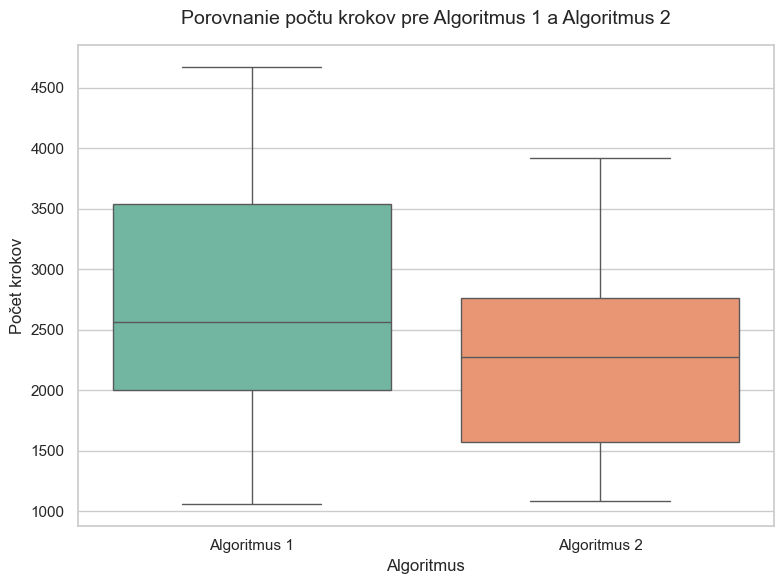

In [37]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x='alg', 
    y='poc_kroku', 
    data=df, 
    hue='alg', 
    palette="Set2", 
    legend=False
)

plt.title('Porovnanie počtu krokov pre Algoritmus 1 a Algoritmus 2', fontsize=14, pad=15)
plt.xlabel('Algoritmus', fontsize=12)
plt.ylabel('Počet krokov', fontsize=12)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Algoritmus 1', 'Algoritmus 2'])

plt.tight_layout()
plt.savefig('boxplot_algoritmy.png', dpi=300)

### Zhrnutie

* Použila som **dvojvýberový nezávislý t-test**. Hodnoty pre `alg1` a `alg2` som si predstavila ako výstupy z dvoch na sebe nezávislých algoritmov, ktoré počítajú kroky.
* Moja nulová hypotéza ($H_0$) predpokladala, že ich populačné stredné hodnoty sú si rovné ($\mu_1 = \mu_2$).
* V prvom kroku bolo treba skontrolovať predpoklady testu, a to **normalitu dát** v oboch výberoch, ktorá sa potvrdila.
* V druhom kroku bolo potrebné vykonať test na zhodu rozptylov (**Levenov test**). Nulovú hypotézu tohto testu som **nezamietla**, a teda rozptyly ($\sigma_1^2$ a $\sigma_2^2$) nie sú od seba štatisticky významne odlišné (predpokladáme takzvanú **homoskedasticitu**).
* Na základe týchto predpokladov som mohla zvoliť **dvojvýberový t-test pre zhodné rozptyly** so stupňami voľnosti $df = n_1 + n_2 - 2$. Z priloženej tabuľky vidíme, že $H_0$ o rovnosti stredných hodnôt **zamietam**, a teda priemerný počet krokov `alg1` sa štatisticky významne líši od `alg2`.
* Na boxplote vidím, že medián pre krabicový graf $Algoritmus1$ je o niečo vyššie a teda v priemere spraví viac krokov.

# JASP OUTPUT

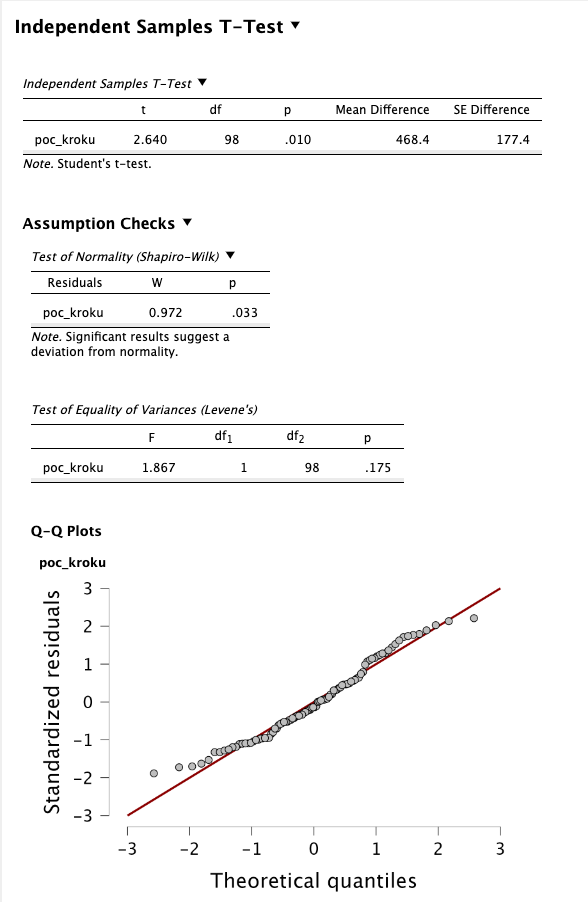